# Analyse de Réseau et Co-occurrence des Tags de Gameplay

## Objectif
Après avoir structuré nos tags dans une taxonomie propre, nous allons analyser les corrélations entre les différentes dimensions (ex: quels genres sont les plus associés à quelles mécaniques ?).

Cette étape est cruciale pour :
1. **Identifier des patterns de design** : Groupements naturels de mécaniques.
2. **Détecter des niches** : Combinaisons de tags rares mais cohérentes.

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# Chargement de la base structurée
df = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# On se concentre sur les Genre et Mechanics pour la co-occurrence
print(f"Base chargée : {df.shape[0]} jeux.")

Base chargée : 100384 jeux.


## 1. Matrice de Co-occurrence Genre vs Mécaniques

Nous allons calculer combien de fois un Genre (ex: RPG) apparaît avec une Mécanique (ex: Crafting).

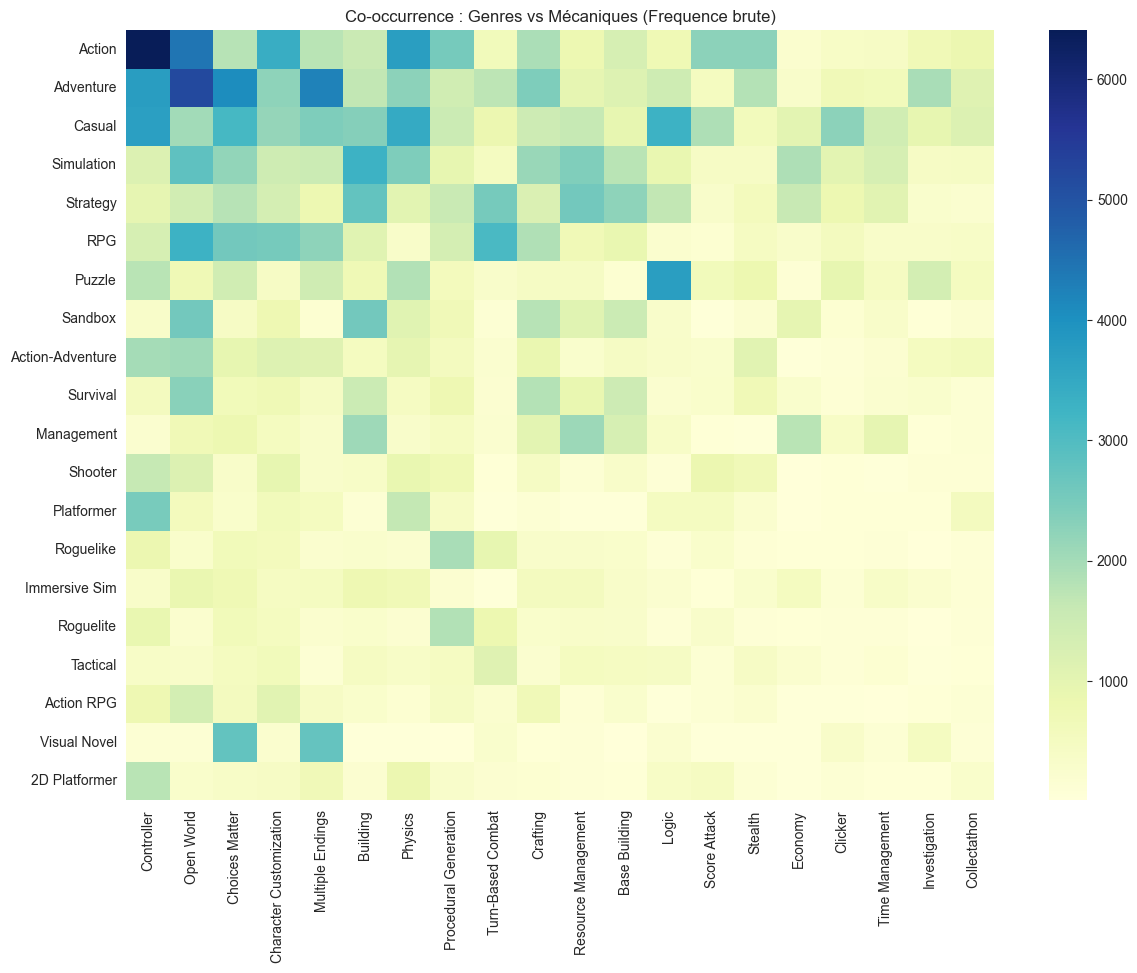

In [10]:
def get_cooccurrence_matrix(df, col1, col2):
    # Extraction des listes de tags
    s1 = df[col1].str.split(', ').fillna('').tolist()
    s2 = df[col2].str.split(', ').fillna('').tolist()
    
    # Liste de tous les tags uniques pour chaque colonne
    tags1 = sorted(list(set([t for sub in s1 for t in sub if t])))
    tags2 = sorted(list(set([t for sub in s2 for t in sub if t])))
    
    matrix = pd.DataFrame(0, index=tags1, columns=tags2)
    
    for i in range(len(s1)):
        for t1 in s1[i]:
            for t2 in s2[i]:
                if t1 and t2:
                    matrix.loc[t1, t2] += 1
    return matrix

cooc_matrix = get_cooccurrence_matrix(df, 'Genre', 'Mechanics')

# Visualisation par Heatmap (Top 20 genres / Top 20 mechanics)
top_genres = cooc_matrix.sum(axis=1).sort_values(ascending=False).head(20).index
top_mechanics = cooc_matrix.sum(axis=0).sort_values(ascending=False).head(20).index

plt.figure(figsize=(14, 10))
sns.heatmap(cooc_matrix.loc[top_genres, top_mechanics], annot=False, cmap="YlGnBu")
plt.title("Co-occurrence : Genres vs Mécaniques (Frequence brute)")
plt.show()

*Cette matrice de corrélation brute montre les associations les plus fréquentes, mais elle est biaisée par la popularité des tags. Par exemple, un genre très populaire comme "Action" apparaîtra souvent avec de nombreuses mécaniques simplement parce qu'il est présent dans beaucoup de jeux. C'est pourquoi nous allons normaliser cette matrice pour mieux comprendre les associations significatives.*

## 2. Analyse de Proximité (Lift/Normalisation)

La fréquence brute favorise les tags populaires. Nous utilisons le Lift pour voir quelles associations sont plus fréquentes que prévu par le simple hasard.

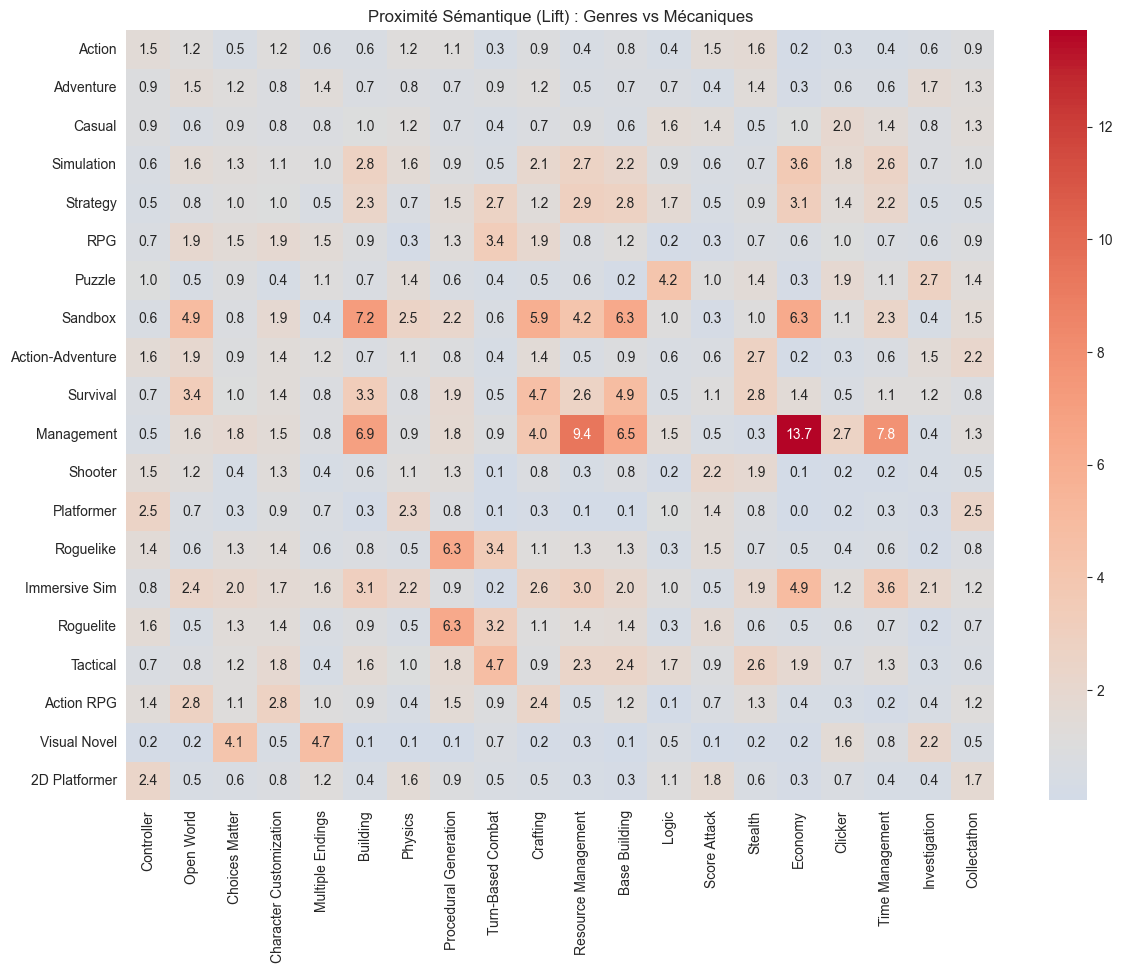

In [11]:
N = len(df)
genre_counts = df['Genre'].str.split(', ').explode().value_counts()
mech_counts = df['Mechanics'].str.split(', ').explode().value_counts()

lift_matrix = cooc_matrix.copy().astype(float)
for g in lift_matrix.index:
    for m in lift_matrix.columns:
        expected = (genre_counts[g] * mech_counts[m]) / N
        if expected > 0:
            lift_matrix.loc[g, m] = cooc_matrix.loc[g, m] / expected
        else:
            lift_matrix.loc[g, m] = 0

plt.figure(figsize=(14, 10))
sns.heatmap(lift_matrix.loc[top_genres, top_mechanics], annot=True, fmt=".1f", cmap="coolwarm", center=1)
plt.title("Proximité Sémantique (Lift) : Genres vs Mécaniques")
plt.show()

*On remarque que certaines associations ont un Lift très élevé, indiquant qu'elles sont beaucoup plus fréquentes que ce à quoi on pourrait s'attendre par hasard. Le genre management par exemple, est très fortement associés à certaines mécaniques telles que l'économie, le management de ressources ou le management de temps. Ces associations sont des patterns de design forts qui semble si forte qu'elles peuvent être perçues comme des "règles" de design. Par exemple, un jeu de management qui n'inclut pas de mécaniques d'économie ou de gestion de ressources serait perçu comme manquant d'éléments essentiels à son genre.*

## 3. Visualisation en Graphe

Création d'un graphe où les nœuds sont les tags et les liens représentent la force de l'association (Lift > 2).

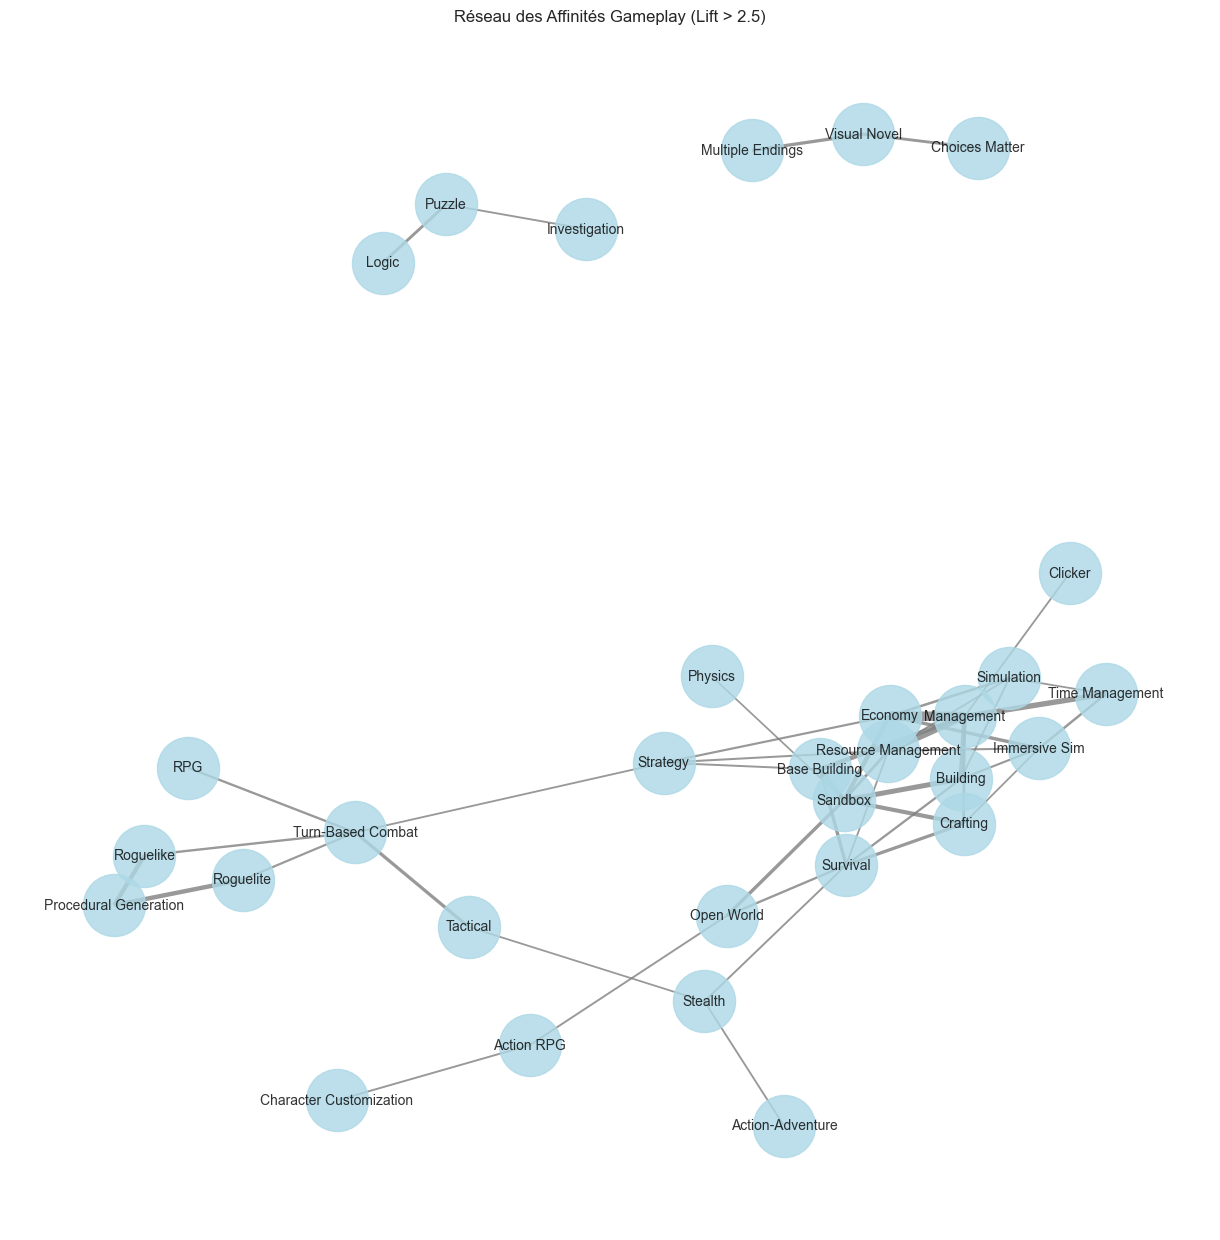

In [12]:
G = nx.Graph()

threshold = 2.5
for g in top_genres:
    for m in top_mechanics:
        weight = lift_matrix.loc[g, m]
        if weight > threshold:
            G.add_edge(g, m, weight=weight)

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, 
        node_color='lightblue', 
        node_size=2000, 
        font_size=10, 
        width=[G[u][v]['weight']*0.5 for u,v in G.edges()],
        edge_color='gray', 
        alpha=0.8)
plt.title(f"Réseau des Affinités Gameplay (Lift > {threshold})")
plt.show()

Certains groupes n'intéragissent pas du tout entre eux, ainsi se forment 3 graphes connexes :
- un relatif aux jeux à puzzle
- un autre relatif au visual novel
- un dernier qui regroupe lui-même plusieurs sous groupes tel que les roguelike, les action rpg, ou encore les jeux de simulation

## Conclusion

L'analyse de réseau a révélé des structures de gameplay très distinctes au sein de la folksonomie Steam.

**Points clés :**
1.  **Clusters de Gameplay** : Nous avons identifié des groupes de genres et de mécaniques qui fonctionnent ensemble de manière cohérente (ex: Puzzle + Logic, RPG + Turn-Based Combat).
2.  **Isolement de certaines niches** : Les Visual Novels et les jeux de Puzzle forment des communautés presque isolées, partageant peu de mécaniques avec les autres genres majeurs comme l'Action ou le RPG.
3.  **Complexité des genres hybrides** : Le grand cluster central (Roguelike, Action RPG, Simulation) montre que ces genres sont beaucoup plus perméables et partagent de nombreuses mécaniques (Crafting, Open World, Procedural Generation), ce qui explique la difficulté de les classer dans une seule catégorie rigide.

**Implications pour la suite :**
Cette analyse confirme que la classification par genre unique est insuffisante. Une approche par "profil de mécaniques" (clustering) semble plus prometteuse pour capturer la diversité des expériences de jeu, en particulier pour les genres hybrides du cluster central. C'est ce que nous explorerons dans le prochain notebook.
